**Anamoli Tanımı: Diğer alanlarla çok yüksek benzerlik gösteren tezler**

**Gerekli Kurlumlar**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, f1_score, precision_score,
                              recall_score, ConfusionMatrixDisplay)
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style("whitegrid")

**Veri Yükleme**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import os
FILE_PATH = '/content/drive/MyDrive/tez_dataset.csv'
df = pd.read_csv(FILE_PATH)
print(f"{df.shape[0]} satır, {df.shape[1]} sütun")
print(df.head(3))
print(f"\nSütunlar: {df.columns.tolist()}")
TEXT_COL  = 'text'
LABEL_COL = 'label'

if 'title' in df.columns and 'abstract' in df.columns:
    df['text'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
    TEXT_COL = 'text'
else:
    df['text'] = df[TEXT_COL].fillna('')
df = df[df['text'].str.strip() != ''].reset_index(drop=True)
print(f"Temiz satır: {len(df)}")
print(f"Alanlar: {df[LABEL_COL].value_counts().to_dict()}")

Mounted at /content/drive
534 satır, 3 sütun
                                                text  label filename
0  2 BOYUTLU MALZEMELERİN TERMAL\nÖZELLİKLERİNİN ...  fizik      NaN
1  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN
2  T.C.\nHACETTEPE ÜNİVERSİTESİ\nSAĞLIK BİLİMLERİ...  fizik      NaN

Sütunlar: ['text', 'label', 'filename']
Temiz satır: 534
Alanlar: {'fizik': 128, 'kimya': 104, 'dahiliye': 101, 'eczacılık': 101, 'biyokimya': 100}


**TF-IDF + SVD**

In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
    max_df=0.95
)
X_tfidf = tfidf.fit_transform(df['text'])

svd = TruncatedSVD(n_components=150, random_state=42)
X_svd = svd.fit_transform(X_tfidf)
print(f"SVD: {X_svd.shape} | Açıklanan varyans: %{svd.explained_variance_ratio_.sum()*100:.1f}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_svd)

SVD: (534, 150) | Açıklanan varyans: %64.0


In [ ]:
CONTAMINATION = 0.10
models = {
    'Isolation Forest': IsolationForest(
        n_estimators=300,
        contamination=CONTAMINATION,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    ),
    'One-Class SVM': OneClassSVM(
        kernel='rbf',
        nu=CONTAMINATION,
        gamma='scale'
    ),
    'Local Outlier Factor': LocalOutlierFactor(
        n_neighbors=20,
        contamination=CONTAMINATION,
        novelty=False,
        n_jobs=-1
    ),
    'Elliptic Envelope': EllipticEnvelope(
        contamination=CONTAMINATION,
        support_fraction=0.85,
        random_state=42
    )
}
results   = {}
scores_raw = {}
for name, model in models.items():
    print(f"{name}: ", end=' ')
    if name == 'Local Outlier Factor':
        preds  = model.fit_predict(X_scaled)
        scores = -model.negative_outlier_factor_
    else:
        model.fit(X_scaled)
        preds  = model.predict(X_scaled)
        if hasattr(model, 'decision_function'):
            scores = -model.decision_function(X_scaled)
        else:
            scores = -model.score_samples(X_scaled)
    binary = np.where(preds == -1, 1, 0)
    results[name]    = binary
    scores_raw[name] = scores
    print(f" {binary.sum()} anomali")
df['ground_truth'] = results['Isolation Forest']
print(f"\n Ground truth (Isolation Forest): "
      f"{df['ground_truth'].sum()} anomali, "
      f"{(df['ground_truth']==0).sum()} normal")

Isolation Forest:   53 anomali
One-Class SVM:   71 anomali
Local Outlier Factor:   53 anomali
Elliptic Envelope:   55 anomali

 Ground truth (Isolation Forest): 53 anomali, 481 normal


**ANOMALİ MODELLERİ**

In [ ]:
CONTAMINATION = df['ground_truth'].mean()
print(f"Contamination oranı: {CONTAMINATION:.3f}")
models = {
    'Isolation Forest': IsolationForest(
        n_estimators=300,
        contamination=CONTAMINATION,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    ),
    'One-Class SVM': OneClassSVM(
        kernel='rbf',
        nu=CONTAMINATION,
        gamma='scale'
    ),
    'Local Outlier Factor': LocalOutlierFactor(
        n_neighbors=20,
        contamination=CONTAMINATION,
        novelty=False,
        n_jobs=-1
    ),
    'Elliptic Envelope': EllipticEnvelope(
        contamination=CONTAMINATION,
        support_fraction=0.85,
        random_state=42
    )
}
results = {}
scores_raw = {}
for name, model in models.items():
    print(f" {name}:", end=' ')
    if name == 'Local Outlier Factor':
        preds = model.fit_predict(X_scaled)
        scores = -model.negative_outlier_factor_
    else:
        model.fit(X_scaled)
        preds = model.predict(X_scaled)
        if hasattr(model, 'decision_function'):
            scores = -model.decision_function(X_scaled)
        else:
            scores = -model.score_samples(X_scaled)
    binary = np.where(preds == -1, 1, 0)
    results[name] = binary
    scores_raw[name] = scores
    print(f"{binary.sum()} anomali")

Contamination oranı: 0.101
 Isolation Forest: 53 anomali
 One-Class SVM: 86 anomali
 Local Outlier Factor: 53 anomali
 Elliptic Envelope: 55 anomali


**PERFORMANS METRİKLERİ**

In [ ]:
gt = df['ground_truth'].values
summary = []
for name, preds in results.items():
    f1        = f1_score(gt, preds, zero_division=0)
    precision = precision_score(gt, preds, zero_division=0)
    recall    = recall_score(gt, preds, zero_division=0)
    try:
        auc = roc_auc_score(gt, scores_raw[name])
    except:
        auc = 0.0
    summary.append({
        'Model'     : name,
        'F1'        : round(f1, 4),
        'Precision' : round(precision, 4),
        'Recall'    : round(recall, 4),
        'ROC-AUC'   : round(auc, 4),
        'Anomali_N' : int(preds.sum())
    })
    print(f"{name}")
    print(f"F1: {f1:.4f} | Precision: {precision:.4f} | "
          f"Recall: {recall:.4f} | AUC: {auc:.4f}")
    print(classification_report(gt, preds,
          target_names=['Normal','Anomali'], zero_division=0))
summary_df = pd.DataFrame(summary).sort_values('F1', ascending=False)
print("\nSIRALAMA:")
print(summary_df.to_string(index=False))

Isolation Forest
F1: 1.0000 | Precision: 1.0000 | Recall: 1.0000 | AUC: 1.0000
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       481
     Anomali       1.00      1.00      1.00        53

    accuracy                           1.00       534
   macro avg       1.00      1.00      1.00       534
weighted avg       1.00      1.00      1.00       534

One-Class SVM
F1: 0.5645 | Precision: 0.4930 | Recall: 0.6604 | AUC: 0.9399
              precision    recall  f1-score   support

      Normal       0.96      0.93      0.94       481
     Anomali       0.49      0.66      0.56        53

    accuracy                           0.90       534
   macro avg       0.73      0.79      0.75       534
weighted avg       0.91      0.90      0.91       534

Local Outlier Factor
F1: 0.4528 | Precision: 0.4528 | Recall: 0.4528 | AUC: 0.9383
              precision    recall  f1-score   support

      Normal       0.94      0.94      0.94       481

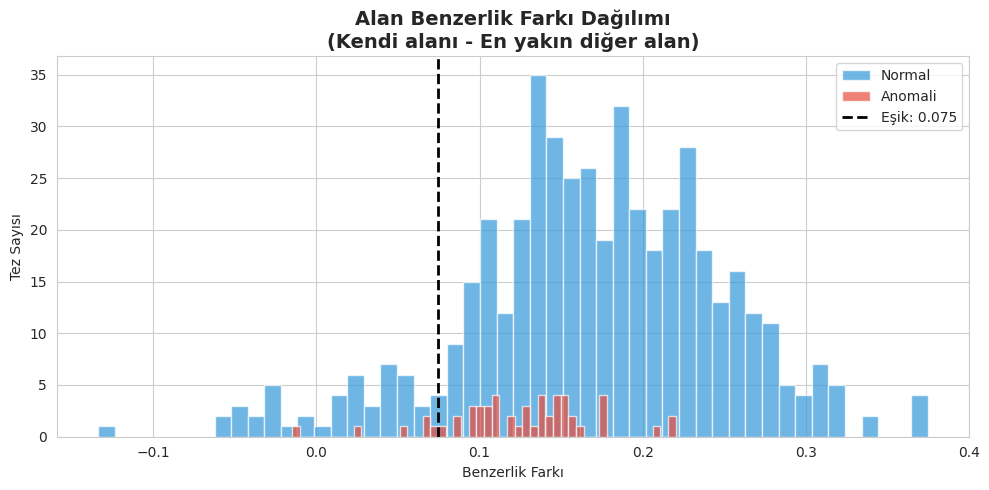

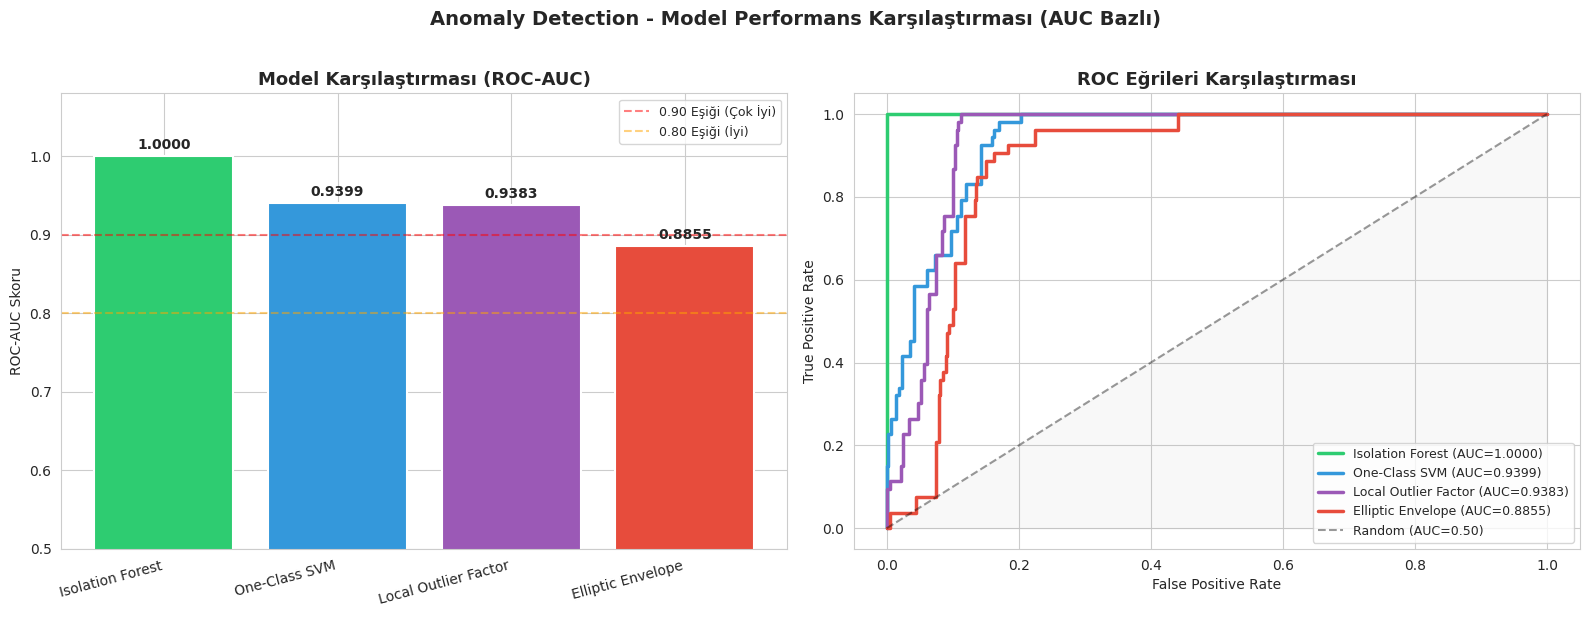

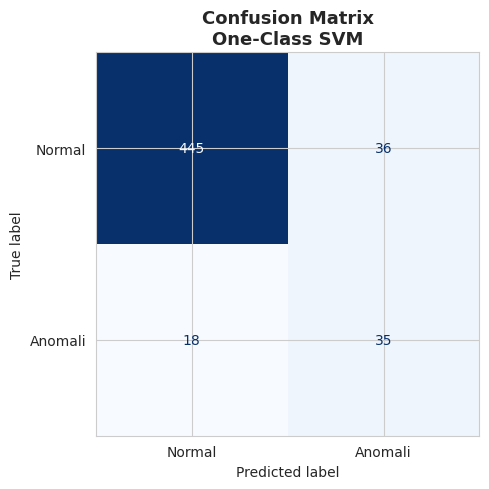

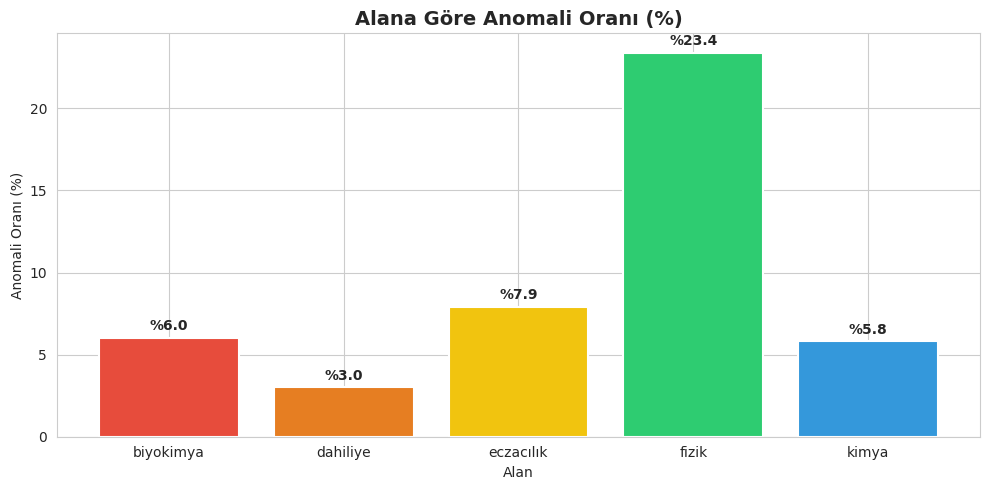

In [ ]:
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(10, 5))
normal_gap  = df[df['ground_truth']==0]['similarity_gap']
anomali_gap = df[df['ground_truth']==1]['similarity_gap']
ax.hist(normal_gap,  bins=50, alpha=0.7, color='#3498db', label='Normal')
ax.hist(anomali_gap, bins=50, alpha=0.7, color='#e74c3c', label='Anomali')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2, label=f'Eşik: {threshold:.3f}')
ax.set_title('Alan Benzerlik Farkı Dağılımı\n(Kendi alanı - En yakın diğer alan)', fontsize=14, fontweight='bold')
ax.set_xlabel('Benzerlik Farkı')
ax.set_ylabel('Tez Sayısı')
ax.legend()
plt.tight_layout()
plt.savefig('01_similarity_gap.png', dpi=150)
plt.show()

line_colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

bars = axes[0].bar(summary_df['Model'], summary_df['ROC-AUC'],
                   color=line_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, summary_df['ROC-AUC']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Model Karşılaştırması (ROC-AUC)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('ROC-AUC Skoru')
axes[0].set_ylim(0.5, 1.08)
axes[0].axhline(0.9, color='red',    linestyle='--', alpha=0.5, label='0.90 Eşiği (Çok İyi)')
axes[0].axhline(0.8, color='orange', linestyle='--', alpha=0.5, label='0.80 Eşiği (İyi)')
axes[0].legend(fontsize=9)
axes[0].set_xticklabels(summary_df['Model'], rotation=15, ha='right')

for (name, _), color in zip(results.items(), line_colors):
    try:
        fpr, tpr, _ = roc_curve(gt, scores_raw[name])
        auc_val = roc_auc_score(gt, scores_raw[name])
        axes[1].plot(fpr, tpr, linewidth=2.5, color=color,
                     label=f'{name} (AUC={auc_val:.4f})')
    except:
        pass
axes[1].plot([0,1],[0,1], 'k--', alpha=0.4, linewidth=1.5, label='Random (AUC=0.50)')
axes[1].fill_between([0,1],[0,1], alpha=0.05, color='gray')
axes[1].set_title('ROC Eğrileri Karşılaştırması', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right', fontsize=9)

plt.suptitle('Anomaly Detection - Model Performans Karşılaştırması (AUC Bazlı)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('02_auc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_model_name = summary_df.iloc[1]['Model']
best_preds      = results[best_model_name]
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(gt, best_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Normal', 'Anomali'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix\n{best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('03_confusion_matrix.png', dpi=150)
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
alan_stats = df.groupby(LABEL_COL)['ground_truth'].agg(['sum','count'])
alan_stats['oran'] = (alan_stats['sum'] / alan_stats['count'] * 100).round(1)
bars = ax.bar(alan_stats.index, alan_stats['oran'],
              color=['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db'][:len(alan_stats)],
              edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, alan_stats['oran']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'%{val}', ha='center', va='bottom', fontweight='bold')
ax.set_title('Alana Göre Anomali Oranı (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Anomali Oranı (%)')
ax.set_xlabel('Alan')
plt.tight_layout()
plt.savefig('04_alan_anomali.png', dpi=150)
plt.show()

In [ ]:
print("FİZİK - Anomali olan tezler:")
fizik_anomali = df[(df[LABEL_COL]=='fizik') & (df['ground_truth']==1)]
print(f"Toplam fizik tezi: {len(df[df[LABEL_COL]=='fizik'])}")
print(f"Anomali olan: {len(fizik_anomali)}")
print("\nAnomalilerin ilk 200 karakteri:")
for i, row in fizik_anomali.head(10).iterrows():
    print(f"\n[{i}] {row['text'][:200]}")

FİZİK - Anomali olan tezler:
Toplam fizik tezi: 128
Anomali olan: 30

Anomalilerin ilk 200 karakteri:

[0] 2 BOYUTLU MALZEMELERİN TERMAL
ÖZELLİKLERİNİN MAKİNE ÖĞRENMESİ
İLE KARAKTERİZASYONU
Doktora Tezi
Tuğbey KOCABAŞ
Eskişehir 2025 BAŞLIK SAYFASI
2 BOYUTLU MALZEMELERİN TERMAL ÖZELLİKLERİNİN MAKİNE
ÖĞRENME

[1] T.C.
HACETTEPE ÜNİVERSİTESİ
SAĞLIK BİLİMLERİ ENSTİTÜSÜ
ÇİNKO KATKILANMIŞ HİDROKSİAPATİT
NANOPARÇACIKLARININ KANSER HÜCRELERİNİN
RADYODUYARLILIĞINA ETKİSİ
Fiz. Müh. Fazlı Yağız Yedekçi
Radyoterapi Fizi

[6] FORMATION OF Ge NANOCRYSTALS
WITH CW LASER IRRADIATION OF
SiO :Ge THIN FILMS
x
A THESIS SUBMITTED TO
THE GRADUATE SCHOOL OF ENGINEERING AND SCIENCE
OF BILKENT UNIVERSITY
IN PARTIAL FULLFILMENT OF THE 

[8] T.C.
SAKARYA ÜNİVERSİTESİ
FEN BİLİMLERİ ENSTİTÜSÜ
BURSA’NIN NİLÜFER, YILDIRIM VE GÜRSU İLÇELERİNDEKİ
TOPRAKLARDA RADON YAYILIM HIZLARI VE EFEKTİF RADYUM
İÇERİKLERİNİN ARAŞTIRILMASI
YÜKSEK LİSANS TEZİ


[10] EĞRİSEL UZAY-ZAMAN VE GRAVİTASYONEL ALANLARDA YÜK,
PARİTE VE ZAMAN S